In [2]:
%load_ext autoreload
%autoreload 2

import os, sys
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from itertools import product
import torchvision
from matplotlib import colors
import matplotlib.patches as patches
from sklearn.cluster import KMeans

sys.path.append(os.path.join(os.getcwd(), '../symlie'))
sys.path.append(os.path.join(os.getcwd(), '../sympdee/sympde/viz'))
sys.path.append(os.path.join(os.getcwd(), '..'))

from symlie.model.networks.linear import CalculatedP, LinearP
from sympdee.sympde.viz.general_plots import imshows, plot_vals, simple_imshow, savefig, simple_imshow
from symlie.misc.utils_results import get_and_check_Ps, plot_seeds_and_Ps
from symlie.data.transforms import TransformRefactored as Transform

from symlie.model.networks.mlp import CombiMLP
from symlie.model.learner import CombiLearner
from symlie.misc.viz import wb_plot_pred
from symlie.run import parse_options, main, process_args
from symlie.misc.viz import wb_plot_pred

from symlie.data.transforms import TransformRefactored

from emlp.reps import V, vis
from emlp.groups import Z, O
from emlp.datasets import O5Synthetic
from emlp.nn import gated,gate_indices,uniform_rep
from symlie.misc.viz import wb_plot_pred


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
size = 16
linear = LinearP(in_features=size, out_features=size, bias=False, P_init='space_translation')
linear.weight.data = torch.arange(linear.out_features*linear.in_features).reshape(linear.out_features, linear.in_features).float()


In [35]:
# Apply the weight mapping
weight = (linear.P @ linear.weight.flatten()).reshape(linear.weight.shape)
weight = weight.detach().numpy()

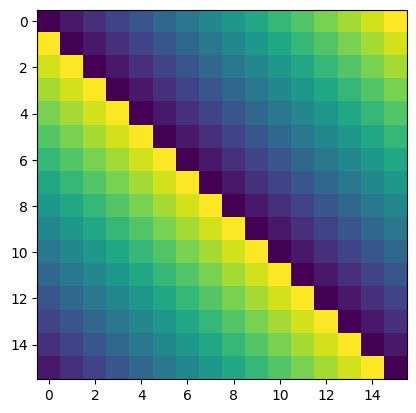

In [36]:
# w = linear.weight.data.numpy()
w  = weight

plt.imshow(w)